In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)

In [18]:
df = pd.read_csv("../data/bank-full.csv", sep = ';')

print(df.shape)

df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [19]:
df['subscription'] = df['y'].map({
    'yes': 1,
    'no': 0
})

print(df['subscription'].value_counts())

subscription
0    39922
1     5289
Name: count, dtype: int64


In [20]:
scaler = MinMaxScaler()

df['balance_scaled'] = scaler.fit_transform(df[['balance']])

df['duration_scaled'] = scaler.fit_transform(df[['duration']])

df['previous_scaled'] = scaler.fit_transform(df[['previous']])

df['CLV_Score'] = (
    0.5 * df['balance_scaled']
    + 0.3 * df['duration_scaled']
    +0.2 * df['previous_scaled']
)

In [21]:
df['CLV_Segment'] = pd.qcut(
    df['CLV_Score'].rank(method='first'),
    q = 4,
    labels= [
        'Low Value',
        'Medium Value',
        'High Value',
        'VIP'
    ]
)

print(df['CLV_Segment'].value_counts())


CLV_Segment
Low Value       11303
Medium Value    11303
VIP             11303
High Value      11302
Name: count, dtype: int64


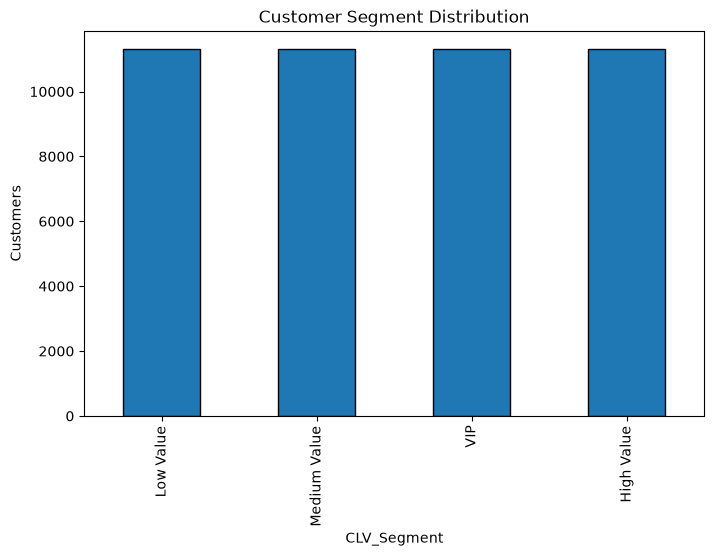

In [22]:
segment_count = (
    df['CLV_Segment'].value_counts()
)

plt.figure(figsize=(8,5))

segment_count.plot(kind='bar', edgecolor = 'black')

plt.title("Customer Segment Distribution")
plt.ylabel("Customers")

plt.show()

### Customer Segment Distribution

Customers were divided into four customer value segments using quartile-based CLV scoring. The segmentation method ensures that each segment contains approximately the same number of customers, enabling fair comparison across customer groups.

#### Key Insight

- The distribution is balanced across all segments because quartile-based segmentation was applied.
- Each segment represents approximately 25% of the customer base.
- This balanced segmentation supports unbiased comparison of customer behavior, subscription rates, and financial value.

#### Business Value

The segmentation creates a structured framework for identifying high-value customers, prioritizing retention strategies, and designing targeted marketing campaigns.

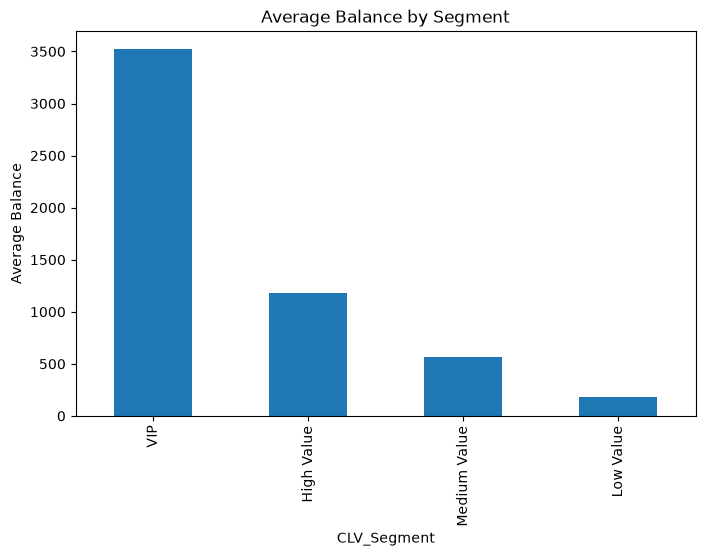

CLV_Segment
VIP             3521.045209
High Value      1179.228898
Medium Value     570.275060
Low Value        178.522870
Name: balance, dtype: float64


In [23]:
avg_balance = (
    df.groupby('CLV_Segment')['balance'].mean().sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

avg_balance.plot(kind='bar')

plt.title("Average Balance by Segment")
plt.ylabel("Average Balance")

plt.show()

print(avg_balance)

### Average Balance by Customer Lifetime Value (CLV) Segment

This chart compares the average account balance across different CLV segments.

#### Key Findings

- VIP customers have the highest average balance, exceeding $3,500.
- High Value customers maintain significantly higher balances than Medium and Low Value segments.
- Medium Value customers show moderate account balances.
- Low Value customers have the lowest average balance among all segments.

#### Business Insight

A clear positive relationship exists between customer value and account balance. Customers with larger balances tend to generate higher lifetime value for the bank.

#### Business Recommendation

- Prioritize VIP and High Value customers through personalized relationship management and premium banking services.
- Design retention campaigns for Medium Value customers to encourage migration into higher-value segments.
- Introduce targeted cross-selling and engagement strategies for Low Value customers to increase account activity and balance growth.

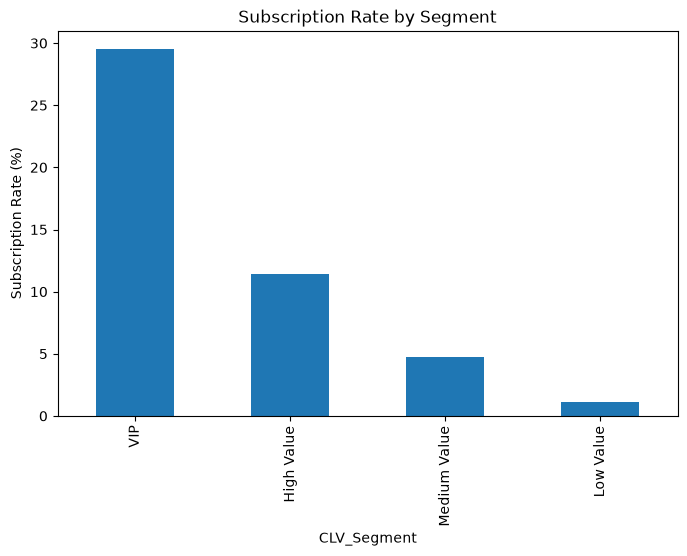

CLV_Segment
VIP             29.505441
High Value      11.458149
Medium Value     4.724409
Low Value        1.105901
Name: subscription, dtype: float64


In [24]:
segment_sub = (
    df.groupby('CLV_Segment')['subscription'].mean()*100
)

segment_sub = segment_sub.sort_values(ascending=False)

plt.figure(figsize=(8,5))
segment_sub.plot(kind='bar')

plt.title("Subscription Rate by Segment")
plt.ylabel("Subscription Rate (%)")

plt.show()

print(segment_sub)

### Subscription Rate by CLV Segment

This chart shows the percentage of customers who subscribed to the bank's term deposit product across different Customer Lifetime Value (CLV) segments.

#### Key Findings

- VIP customers have the highest subscription rate at approximately 30%.
- High Value customers show a moderate subscription rate of around 11%.
- Medium Value customers have a lower subscription rate of roughly 5%.
- Low Value customers exhibit the lowest subscription rate at approximately 1%.

#### Business Insight

Customer Lifetime Value is strongly associated with subscription behavior. Customers with higher balances and greater financial value are significantly more likely to subscribe to term deposit products.

#### Business Recommendation

- Prioritize VIP customers for premium deposit and investment offerings.
- Target High Value customers with personalized marketing campaigns to improve conversion rates.
- Develop engagement and financial education programs for Medium and Low Value customers to increase product adoption.

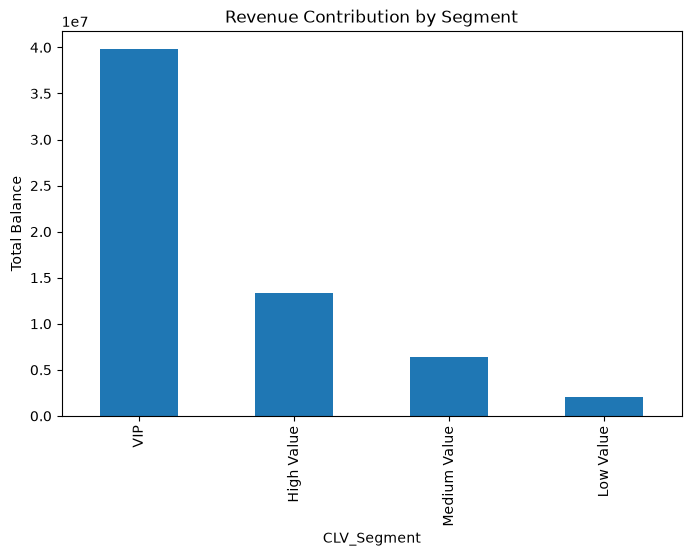

CLV_Segment
VIP             39798374
High Value      13327645
Medium Value     6445819
Low Value        2017844
Name: balance, dtype: int64


In [25]:
segment_balance = (
    df.groupby('CLV_Segment')['balance']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

segment_balance.plot(kind='bar')

plt.title("Revenue Contribution by Segment")
plt.ylabel("Total Balance")

plt.show()

print(segment_balance)

### Revenue Contribution by CLV Segment

This chart illustrates the total account balance contributed by each Customer Lifetime Value (CLV) segment.

#### Key Findings

- VIP customers contribute the highest share of total balance, accounting for nearly ₹40 million.
- High Value customers contribute the second-largest share with approximately ₹13 million.
- Medium Value customers contribute around ₹6 million.
- Low Value customers contribute the smallest share, contributing only about ₹2 million.

#### Business Insight

The majority of the bank's financial value is concentrated among VIP and High Value customers. Although these segments represent only a portion of the customer base, they generate a disproportionately large share of total deposits and revenue potential.

#### Business Recommendation

- Prioritize retention strategies for VIP customers to protect the bank's most valuable assets.
- Offer premium banking, wealth management, and investment products to VIP and High Value customers.
- Design targeted upselling campaigns for Medium Value customers to move them into higher-value segments.
- Reduce acquisition costs for Low Value customers and focus on increasing engagement before promoting premium products.

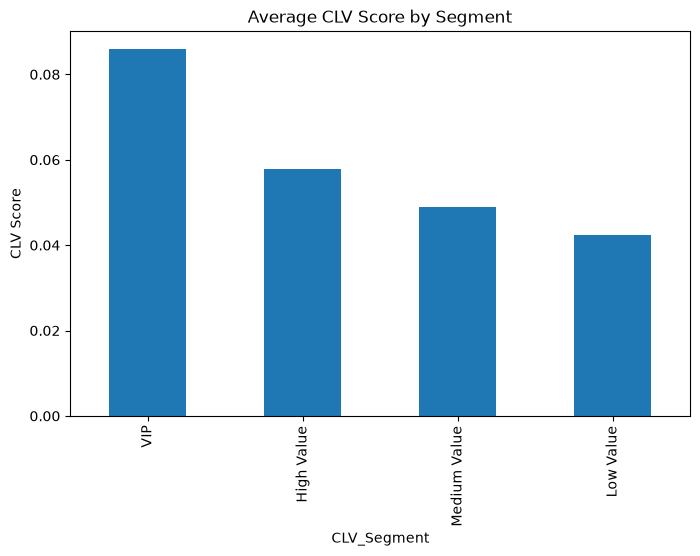

CLV_Segment
VIP             0.085885
High Value      0.057811
Medium Value    0.049037
Low Value       0.042290
Name: CLV_Score, dtype: float64


In [26]:
avg_clv = (
    df.groupby('CLV_Segment')['CLV_Score'].mean().sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
avg_clv.plot(kind='bar')

plt.title("Average CLV Score by Segment")
plt.ylabel("CLV Score")

plt.show()

print(avg_clv)

### Average CLV Score by Segment

This chart compares the average Customer Lifetime Value (CLV) score across different customer segments.

#### Key Findings

- VIP customers have the highest average CLV score at approximately 0.086.
- High Value customers have the second-highest CLV score at around 0.058.
- Medium Value customers show a moderate CLV score of approximately 0.049.
- Low Value customers have the lowest average CLV score at roughly 0.042.

#### Business Insight

The CLV segmentation successfully differentiates customers based on their long-term financial value. VIP customers consistently generate the highest customer value, while Low Value customers contribute the least. The clear separation between segments validates the effectiveness of the CLV scoring methodology.

#### Business Recommendation

- Focus premium banking services and personalized relationship management on VIP customers.
- Target High Value customers with cross-selling and upselling opportunities to increase their lifetime value.
- Develop engagement campaigns for Medium Value customers to encourage higher product adoption.
- Implement retention and financial education programs for Low Value customers to improve their profitability over time.

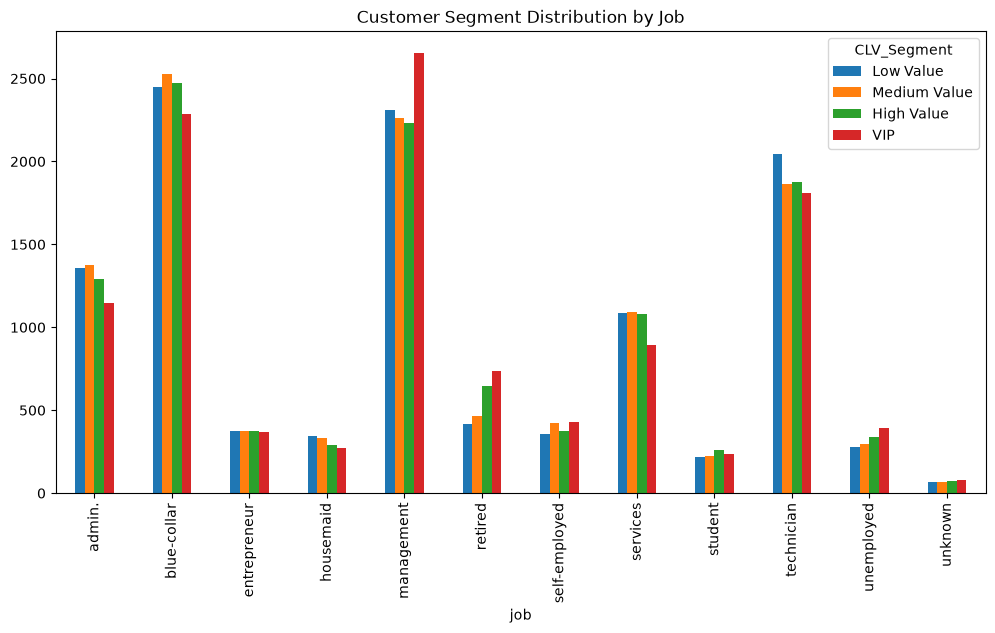

In [27]:
segment_job = pd.crosstab(
    df['job'],
    df['CLV_Segment']
)

segment_job.plot(kind='bar', figsize=(12,6))

plt.title("Customer Segment Distribution by Job")

plt.show()

### Customer Segment Distribution by Job

This chart analyzes the distribution of Customer Lifetime Value (CLV) segments across different occupational groups.

#### Key Findings

- Management professionals represent the largest share of VIP customers, indicating strong financial value and profitability.
- Blue-collar and technician occupations contribute a significant number of customers across all CLV segments.
- Retired customers have a noticeably higher concentration in the High Value and VIP segments compared to many working professions.
- Students and unemployed customers are present across segments but contribute a smaller share of VIP customers.
- Entrepreneur and self-employed customers show a relatively balanced distribution across Medium, High Value, and VIP categories.

#### Business Insight

Occupation plays an important role in customer value segmentation. Management professionals and retired customers tend to exhibit higher financial value, while blue-collar and technician customers form the largest customer base. This suggests that customer acquisition and retention strategies should be tailored according to occupational profiles.

#### Business Recommendation

- Prioritize wealth management and premium banking services for management and retired customers.
- Develop targeted savings and investment products for technicians and blue-collar customers to increase their lifetime value.
- Create specialized financial planning solutions for self-employed and entrepreneur segments.
- Offer entry-level investment and credit products to students and unemployed customers to nurture future high-value relationships.

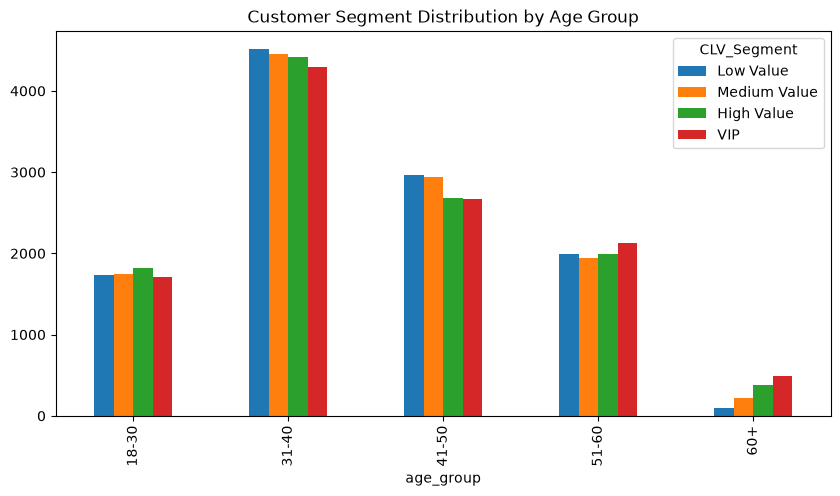

In [28]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,60,100],
    labels=[
        '18-30',
        '31-40',
        '41-50',
        '51-60',
        '60+'
    ]
)

segment_age = pd.crosstab(
    df['age_group'],
    df['CLV_Segment']
)

segment_age.plot(kind='bar', figsize=(10,5))

plt.title("Customer Segment Distribution by Age Group")

plt.show()

### Customer Segment Distribution by Age Group

This chart examines how Customer Lifetime Value (CLV) segments are distributed across different age groups.

#### Key Findings

- Customers aged 31–40 represent the largest customer group across all CLV segments.
- The 41–50 age group is the second-largest contributor, maintaining a strong presence in all customer value categories.
- Customers aged 51–60 show a relatively higher concentration in the VIP segment compared to younger age groups.
- The 60+ age group contains the smallest number of customers but exhibits a larger proportion of VIP customers relative to its size.
- The 18–30 segment contributes a moderate number of customers but has fewer VIP customers compared to older age groups.

#### Business Insight

Customer value generally increases with age. Older customers, particularly those aged 51 and above, are more likely to belong to the VIP segment, suggesting greater financial stability, accumulated savings, and stronger banking relationships.

#### Business Recommendation

- Focus wealth management and investment products on customers aged 51+.
- Target customers aged 31–50 with cross-selling and premium banking campaigns to move them into higher-value segments.
- Develop long-term relationship programs for younger customers (18–30) to increase future lifetime value.
- Create age-specific marketing strategies to maximize customer engagement and profitability.

In [29]:

df.to_csv("../data/bank_customer_segments.csv", index=False)

print("File Saved Successfully")

File Saved Successfully


In [36]:
# Add segment information to original dataframe

df['Segment'] = df['CLV_Segment']

# CLV Score

df['CLV_Score'] = (
    df['balance'] * df['subscription']
) / (
    df['campaign'] + 1
)

# CLV Segment

df['CLV_Segment'] = pd.qcut(
    df['CLV_Score'].rank(method='first'),
    q=4,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'VIP'
    ]
)


df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscription,balance_scaled,duration_scaled,previous_scaled,CLV_Score,CLV_Segment,age_group,Segment
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,0.092259,0.053070,0.0,0.0,Low Value,51-60,High Value
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,0.073067,0.030704,0.0,0.0,Low Value,41-50,Low Value
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,0.072822,0.015453,0.0,0.0,Low Value,31-40,Low Value
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,0.086476,0.018707,0.0,0.0,Low Value,41-50,Medium Value
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,0.072812,0.040260,0.0,0.0,Low Value,31-40,Medium Value


In [37]:
df.to_csv(
    "../data/banking_dashboard_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully
